# Phase 3 — Continuous Decoding · DANDI_000688 (S3)

Predicts hand velocity (vx, vy) from binned spike counts using Ridge, Wiener filter,
and Kalman filter on DANDI_000688 (~54 electrodes, vx ≠ vy confirmed).

| Cell | Content |
|------|---------|
| 1 | Imports + AWS credentials |
| 2 | S3 connection + session load (DANDI_000688) |
| 3 | Feature extraction: binned spikes (X), mean-pooled velocity (y), inter-trial filter |
| 4 | Temporal 80/20 train/test split (`shuffle=False`) |
| 5 | Ridge decoder |
| 6 | Wiener filter decoder |
| 7 | Kalman filter decoder |
| 8 | Summary table |
| 9 | Predicted vs actual velocity plots |

**Prerequisites:** AWS credentials for the `cv-pc` profile must be present in
`~/.aws/credentials`. If the S3 connection fails, set up credentials with
`aws configure --profile cv-pc` or copy the key/secret from the lab's shared
credentials file before running Cell 2.

In [2]:
from pathlib import Path
from sklearn.decomposition import PCA
import sys
_repo_root = Path.cwd() if (Path.cwd() / "decoding").is_dir() else Path.cwd().parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

import os
import configparser
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bci_decoding_dataset import DatasetLoader

from decoding import (
    compute_bin_phases,
    compute_binned_counts,
    compute_binned_trial_ids,
    DimReducer,
    KalmanFilterDecoder,
    RidgeDecoder,
    WienerFilterDecoder,
    WienerRidgeDecoder,
)

sns.set_theme(style="whitegrid", font_scale=1.1)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

# ── Pipeline parameters (only values that may need tuning) ──────────────────
BIN_SIZE_MS = 50    # spike binning window (ms)
N_LAGS      = 10     # Wiener filter: past bins appended as features
TRAIN_FRAC  = 0.80  # temporal train/test split
PLOT_BINS   = 200   # bins shown in trace plots

# ── AWS credentials from ~/.aws/credentials ─────────────────────────────────
#credentials_path = os.path.expanduser("~/.aws/credentials")
#config = configparser.ConfigParser()
#config.read(credentials_path)
#profile = os.environ.get("AWS_PROFILE", "cv-pc")

# ── Local dataset path ───────────────────────────────────────────────────────
LOCAL_DATASET_PATH = "/home/camilavelasquez/Documents/Datasets/Combined_Motor_Datasets_v9.zarr"

print("✓ All imports successful")
print(f"bin_size_ms  : {BIN_SIZE_MS}  |  n_lags: {N_LAGS}  |  train: {int(TRAIN_FRAC*100)}%")
print(f"Dataset path : {LOCAL_DATASET_PATH}")

✓ All imports successful
bin_size_ms  : 50  |  n_lags: 10  |  train: 80%
Dataset path : /home/camilavelasquez/Documents/Datasets/Combined_Motor_Datasets_v9.zarr


## S3 Connection + Session Load

DANDI_000688 has ~54 electrodes, ~111 sessions, ~180 trials/session.
Velocity has been confirmed correct for this dataset (vx ≠ vy).

In [3]:
#loader = DatasetLoader(
    #aws_store=True,
    #s3_bucket="solzbacher-lab-motor-decoding-ds",
    #s3_key="datasets/Combined_Motor_Datasets",
    #aws_access_key_id=config[profile]["aws_access_key_id"],
    #aws_secret_access_key=config[profile]["aws_secret_access_key"],)

# AHORA
loader = DatasetLoader(
    aws_store=False,
    combined_dataset_path="/home/camilavelasquez/Documents/Datasets/Combined_Motor_Datasets_V9.zarr",
)

sessions  = loader.filter_sessions("dataset_id", "DANDI_000688")
session_id = sessions[8] #1 es 688 subject T 

#8 es subject T 64 electrodos, 20130905
#22 es la 20131203 subject C
ds = loader.get_processed_data_from_session(session_id)

print(f"Session:        {session_id}")
print(f"Subject:        {ds.attrs.get('subject_id', 'unknown')}")
#el subject_id is not in the attributes of the dataset

print(f"Task:           {ds.attrs.get('task_type', 'unknown')}")
print(f"Sampling rate:  {ds.attrs.get('sampling_rate', 'unknown')} Hz")
print(f"Spikes shape:   {ds['spikes'].shape}  (n_electrodes \u00d7 n_time)")
print(f"Velocity shape: {ds['velocity'].shape}")
print("✓ Connected to local dataset and session loaded")
print(ds.attrs)  

Reading data from session: 20130905
Session:        20130905
Subject:        unknown
Task:           center_out
Sampling rate:  1000.0 Hz
Spikes shape:   (64, 908452)  (n_electrodes × n_time)
Velocity shape: (908452, 2)
✓ Connected to local dataset and session loaded
{'acceleration_max': [194.67339503043775, 226.49851125435478], 'acceleration_min': [-182.15960105029492, -223.6989634018389], 'dataset_id': 'DANDI_000688', 'n_trials': 212, 'normalization_method': 'global-z-score-p99', 'normalization_range': [-1.0, 1.0], 'position_max': [8.937249688941721, 8.09112365937505], 'position_min': [-8.499455731113205, -8.604610908206524], 'sampling_rate': 1000.0, 'task_type': 'center_out', 'velocity_global_mean': [-0.00025834030378904424, 0.00040956493699241303], 'velocity_global_scale': [3.4987658949644596, 3.865083030202896], 'velocity_global_std': [7.3848952223456275, 6.848592494879897]}


In [4]:
print(dict(loader.combined_zarr[session_id].attrs))

{'.specloc': 'specifications', 'dataset_id': 'DANDI_000688', 'decoding_type': 'motor', 'namespace': 'core', 'neurodata_type': 'NWBFile', 'nwb_version': '2.9.0', 'object_id': 'fe9e3984-6689-43be-9e44-242a1f12e5a4', 'subject_id': 'T', 'task_type': 'center_out'}


In [5]:
trial_id_raw = ds["trial_id"].values  # (n_time,)
print(f"trial_id shape: {trial_id_raw.shape}")
print(f"primeros valores: {trial_id_raw[:10]}")
print(f"unique trials: {np.unique(trial_id_raw)[:10]}")
print(f"n_trials únicos: {len(np.unique(trial_id_raw))}")

trial_id shape: (908452,)
primeros valores: [1 1 1 1 1 1 1 1 1 1]
unique trials: [-204 -203 -194 -193 -192 -191 -190 -157 -156 -145]
n_trials únicos: 213


In [7]:
print(f"IDs negativos: {np.sum(trial_id_raw < 0)} timesteps")
print(f"IDs positivos: {np.sum(trial_id_raw > 0)} timesteps")
print(f"IDs = 0: {np.sum(trial_id_raw == 0)} timesteps")
print(f"\nTodos los unique IDs: {np.unique(trial_id_raw)}")

IDs negativos: 88106 timesteps
IDs positivos: 761269 timesteps
IDs = 0: 59077 timesteps

Todos los unique IDs: [-204 -203 -194 -193 -192 -191 -190 -157 -156 -145 -137 -136 -132 -121
 -120 -119 -107 -105  -97  -93  -92  -88  -87  -76  -72  -62  -45  -36
  -35  -32  -27  -26  -25  -11  -10   -5   -4    0    1    2    3    6
    7    8    9   12   13   14   15   16   17   18   19   20   21   22
   23   24   28   29   30   31   33   34   37   38   39   40   41   42
   43   44   46   47   48   49   50   51   52   53   54   55   56   57
   58   59   60   61   63   64   65   66   67   68   69   70   71   73
   74   75   77   78   79   80   81   82   83   84   85   86   89   90
   91   94   95   96   98   99  100  101  102  103  104  106  108  109
  110  111  112  113  114  115  116  117  118  122  123  124  125  126
  127  128  129  130  131  133  134  135  138  139  140  141  142  143
  144  146  147  148  149  150  151  152  153  154  155  158  159  160
  161  162  163  164  165  166  167  

In [6]:
print(f"vx std (post-norm): {y[:, 0].std():.4f}")
print(f"vy std (post-norm): {y[:, 1].std():.4f}")
print(f"vx range: [{y[:, 0].min():.3f}, {y[:, 0].max():.3f}]")
print(f"n_trials: {ds.attrs.get('n_trials', 'unknown')}, active bins: {active_mask.sum()}")
print(f"Session: {session_id}")

#std / (max - min) = 0.17 / (0.82 - (-0.86)) = 0.17 / 1.68 ≈ 0.10 10% rango
#la media es casi que cero 
#0.4 std buscar 

NameError: name 'y' is not defined

In [ ]:
sessions = loader.filter_sessions("dataset_id", "DANDI_000688")
for i, s in enumerate(sessions):
    print(f"[{i}] {s}")

[0] 20130819
[1] 20130820
[2] 20130821
[3] 20130822
[4] 20130823
[5] 20130830
[6] 20130903
[7] 20130904
[8] 20130905
[9] 20130906
[10] 20130909
[11] 20130910
[12] 20131003
[13] 20131009
[14] 20131010
[15] 20131011
[16] 20131022
[17] 20131023
[18] 20131028
[19] 20131029
[20] 20131031
[21] 20131101
[22] 20131203
[23] 20131204
[24] 20131209
[25] 20131210
[26] 20131212
[27] 20131213
[28] 20131217
[29] 20131218
[30] 20131219
[31] 20131220
[32] 20140114
[33] 20140115
[34] 20140116
[35] 20140203
[36] 20140214
[37] 20140217
[38] 20140218
[39] 20140221
[40] 20140224
[41] 20140303
[42] 20140304
[43] 20140306
[44] 20140307
[45] 20140626
[46] 20140627
[47] 20140929
[48] 20141203
[49] 20150309
[50] 20150311
[51] 20150312
[52] 20150313
[53] 20150316
[54] 20150317
[55] 20150318
[56] 20150319
[57] 20150320
[58] 20150511
[59] 20150512
[60] 20150610
[61] 20150611
[62] 20150612
[63] 20150615
[64] 20150616
[65] 20150617
[66] 20150623
[67] 20150625
[68] 20150626
[69] 20150629
[70] 20150630
[71] 20150701
[7

## Feature Extraction

`compute_binned_counts` sums spikes in non-overlapping 50 ms windows → `(n_bins, n_electrodes)`.
Velocity is mean-pooled over the same windows to produce one target per bin.

Inter-trial bins (`trial_phase == 0`) are removed so the decoder trains and evaluates
only on neural states that accompany active task performance.

In [ ]:
X_all      = compute_binned_counts(ds, bin_size_ms=BIN_SIZE_MS)   # (n_bins, n_el) 
n_bins     = X_all.shape[0]
bin_phases = compute_bin_phases(ds, bin_size_ms=BIN_SIZE_MS)       # (n_bins,)
trial_id_binned = compute_binned_trial_ids(ds, bin_size_ms=BIN_SIZE_MS)  # (n_bins,)

velocity  = ds["velocity"].values          # (n_time, 2), float32
n_trimmed = n_bins * BIN_SIZE_MS
y_all = velocity[:n_trimmed].reshape(n_bins, BIN_SIZE_MS, 2).mean(axis=1)  # (n_bins, 2)

active_mask = trial_id_binned > 0
X = X_all[active_mask]
y = y_all[active_mask]

print(f"All bins:    X (X_all)={X_all.shape}   y (Y_all)={y_all.shape}")
print(f"Active bins: X (X_all)={X.shape}   y (y_all)={y.shape}")

print(f"Dropped {(~active_mask).sum()} inter-trial bins ({(~active_mask).mean()*100:.1f}%)")

print(f"vx range: [{y[:, 0].min():.3f}, {y[:, 0].max():.3f}]") #para verificar normalización min max [-1,1] 
#valor_normalizado = 2 × (x - x_min) / (x_max - x_min) - 1
print(f"vy range: [{y[:, 1].min():.3f}, {y[:, 1].max():.3f}]")
assert not np.allclose(y[:, 0], y[:, 1]), "vx == vy bug detected — wrong dataset"
print("✓ vx ≠ vy confirmed")

All bins:    X (X_all)=(18169, 64)   y (Y_all)=(18169, 2)
Active bins: X (X_all)=(16988, 64)   y (y_all)=(16988, 2)
Dropped 1181 inter-trial bins (6.5%)
vx range: [-0.858, 0.823]
vy range: [-1.055, 0.979]
✓ vx ≠ vy confirmed


## Train/Test Split

Single temporal cutpoint at 80%: first 80% of active bins → train, last 20% → test.
`shuffle=False` is mandatory — shuffling leaks future neural state into training,
producing optimistically biased R² on time-series data.

Kfold cross validation: mezcla pasado y futuro por que mezcla bins aleatoriamente entre train y test. Un bin del minuto 2 puede quedar en test y un bin del minuto 8 puede quedar en test. Hay leakage de información temporal. Neural activity tiene relación temporal, lo que pasó hace 100 ms influye en lo de ahora. 

In [ ]:
split = int(len(X) * TRAIN_FRAC)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {X_train.shape[0]} bins  ({X_train.shape[0] * BIN_SIZE_MS / 1000:.1f} s)")
print(f"Test:  {X_test.shape[0]} bins   ({X_test.shape[0] * BIN_SIZE_MS / 1000:.1f} s)")

Train: 13590 bins  (679.5 s)
Test:  3398 bins   (169.9 s)


In [ ]:
#yo los calculo:

print(f"X_train shape: {X_train.shape}")  # (n_bins, n_electrodes)
#Por qué me salen 294 electrodos???
print(f"X_all shape: {X_all.shape}")           # debería ser (n_bins, n_electrodes)


#spikes:
print(f"Spikes: {ds['spikes'].shape}")  # (n_electrodes, n_time)
print(f"n_electrodes según catalog: {[s for s in sessions_T if s['session_id'] == '20131203']}")

X_train shape: (13590, 64)
X_all shape: (18169, 64)
Spikes: (64, 908452)
n_electrodes según catalog: [{'session_id': '20131203', 'dataset_id': 'DANDI_000688', 'subject_id': 'C', 'task_type': 'center_out', 'n_electrodes': 47, 'n_timesteps': 1318302, 'duration_s': 1318.302}]


## PCA


In [ ]:
n_components = min(X_train.shape[0], X_train.shape[1]) - 1
pca_raw = PCA(n_components=n_components)
pca_raw.fit(X_train)

cumvar = np.cumsum(pca_raw.explained_variance_ratio_)
for threshold in [0.50, 0.70, 0.80, 0.90]:
    n = np.searchsorted(cumvar, threshold) + 1
    print(f"{threshold*100:.0f}% varianza → {n} componentes")

print(f"\nTotal componentes disponibles: {n_components}")
print(f"Varianza total explicada: {cumvar[-1]*100:.1f}%")

50% varianza → 12 componentes
70% varianza → 21 componentes
80% varianza → 27 componentes
90% varianza → 38 componentes

Total componentes disponibles: 63
Varianza total explicada: 100.0%


In [ ]:
N_PCA = 30 # + 80% varianza explicada !!!

pca_raw = PCA(n_components=N_PCA)
X_train_pca = pca_raw.fit_transform(X_train)   # fit solo en train
X_test_pca  = pca_raw.transform(X_test)        # transform en test

print(f"X_train: {X_train.shape} → {X_train_pca.shape}")
print(f"X_test:  {X_test.shape}  → {X_test_pca.shape}")
print(f"Varianza explicada: {pca_raw.explained_variance_ratio_.sum()*100:.1f}%")

X_train: (13590, 64) → (13590, 30)
X_test:  (3398, 64)  → (3398, 30)
Varianza explicada: 84.2%


## Ridge Decoder

Ridge minimises RSS + L2 penalty on coefficient magnitudes.
The penalty (alpha) prevents overfitting when n_features is comparable to n_bins.
This is the simplest sensible benchmark, básico, every more complex method should beat it.

In [ ]:
ridge = RidgeDecoder(alpha=1.0)
ridge.fit(X_train_pca, y_train)

r2_ridge      = ridge.score(X_test_pca, y_test)
y_pred_ridge  = ridge.predict(X_test_pca)

print(f"Ridge  R² vx = {r2_ridge[0]:.4f}")
print(f"Ridge  R² vy = {r2_ridge[1]:.4f}")

Ridge  R² vx = 0.0454
Ridge  R² vy = 0.0662


## Wiener Filter Decoder

Extends Ridge by appending the previous `n_lags` bins as extra features,
giving the model `n_lags × 50 ms` of neural history.
Motor cortex activity leads hand velocity by ~100–200 ms, so temporal lags
are the key advantage over plain Ridge.

In [ ]:
wiener = WienerFilterDecoder(n_lags=N_LAGS)
wiener.fit(X_train_pca, y_train)

r2_wiener     = wiener.score(X_test_pca, y_test)
y_pred_wiener = wiener.predict(X_test_pca)
y_test_wiener = y_test[N_LAGS:]

print(f"Wiener R² vx = {r2_wiener[0]:.4f}  ({N_LAGS} lags = {N_LAGS * BIN_SIZE_MS} ms history)")
print(f"Wiener R² vy = {r2_wiener[1]:.4f}")

Wiener R² vx = 0.2315  (10 lags = 500 ms history)
Wiener R² vy = 0.3076


## Wiener-Ridge Decoder

Combines the Wiener filter's temporal lags with Ridge L2 regularization.
This should help when the lagged feature matrix is high-dimensional and prone to overfitting.

In [ ]:
wiener_ridge = WienerRidgeDecoder(n_lags=N_LAGS, alpha=1.0)
wiener_ridge.fit(X_train_pca, y_train)

r2_wiener_ridge     = wiener_ridge.score(X_test_pca, y_test)
y_pred_wiener_ridge = wiener_ridge.predict(X_test_pca)
y_test_wiener_ridge = y_test[N_LAGS:]

print(f"Wiener-Ridge R² vx = {r2_wiener_ridge[0]:.4f}  ({N_LAGS} lags = {N_LAGS * BIN_SIZE_MS} ms history, alpha=1.0)")
print(f"Wiener-Ridge R² vy = {r2_wiener_ridge[1]:.4f}")

## Kalman Filter Decoder

Probabilistic state-space decoder that propagates an uncertainty estimate (covariance)
forward in time and uses a Kalman gain to balance the transition prediction against
the current neural observation.
Classical BCI gold standard — should outperform both linear baselines on clean velocity data.

`predict(X_test, y_test)` requires the ground-truth test targets: `y_test[0]` seeds
the initial state estimate only; subsequent steps use only neural observations.

In [ ]:
kalman = KalmanFilterDecoder(C=1, lag=5)
#It translates the true system state into the measurable variables, and the state transition model, which describes how the system state evolves over time.
#C observation noise (cuanto confía en la predicción vs la observación)
#C alto más desconfianza. Entre más alto, mejor le va al filter, maybe filtrar?


kalman.fit(X_train_pca, y_train)

r2_kalman     = kalman.score(X_test_pca, y_test)          # shape (2,)
y_pred_kalman = kalman.predict(X_test_pca, y_test)

print(f"Kalman R\u00b2 vx = {r2_kalman[0]:.4f}")
print(f"Kalman R\u00b2 vy = {r2_kalman[1]:.4f}")

Kalman R² vx = -0.1199
Kalman R² vy = -0.1643


In [ ]:
for lag in [0, 1, 2, 3, 4, 5]:
    for c in [0.01, 0.1, 1.0]:
        kalman = KalmanFilterDecoder(C=c, lag=lag)
        kalman.fit(X_train_pca, y_train)
        r2 = kalman.score(X_test_pca, y_test)
        print(f"lag={lag}, C={c:.2f} → R² vx={r2[0]:.4f}, vy={r2[1]:.4f}")

 #   lag=3, C=1.00 → R² vx=0.0516, vy=-0.0150    
 #con un C más grande y un lag más grande funciona mejor c y lag 2 v

lag=0, C=0.01 → R² vx=-6.6204, vy=-5.7633
lag=0, C=0.10 → R² vx=-1.8852, vy=-1.9386
lag=0, C=1.00 → R² vx=-0.0796, vy=-0.2403
lag=1, C=0.01 → R² vx=-6.2486, vy=-5.4805
lag=1, C=0.10 → R² vx=-1.7736, vy=-1.8488
lag=1, C=1.00 → R² vx=-0.0822, vy=-0.2013
lag=2, C=0.01 → R² vx=-5.7053, vy=-5.3981
lag=2, C=0.10 → R² vx=-1.6084, vy=-1.8302
lag=2, C=1.00 → R² vx=-0.0757, vy=-0.1689
lag=3, C=0.01 → R² vx=-5.2352, vy=-5.4853
lag=3, C=0.10 → R² vx=-1.4826, vy=-1.8786
lag=3, C=1.00 → R² vx=-0.0712, vy=-0.1478
lag=4, C=0.01 → R² vx=-4.9442, vy=-5.7760
lag=4, C=0.10 → R² vx=-1.4495, vy=-2.0251
lag=4, C=1.00 → R² vx=-0.0848, vy=-0.1489
lag=5, C=0.01 → R² vx=-4.8026, vy=-6.0784
lag=5, C=0.10 → R² vx=-1.4859, vy=-2.2016
lag=5, C=1.00 → R² vx=-0.1199, vy=-0.1643


In [ ]:
#--- KALMAN PARAMETER SEARCH ---
import pandas as pd

results = []
for c in [0.1, 0.5, 1.0, 2.0]:
    for lag in [0, 1, 2, 5]:
        kalman = KalmanFilterDecoder(C=c, lag=lag)
        kalman.fit(X_train, y_train)
        r2 = kalman.score(X_test, y_test)
        results.append({
            "C": c,
            "lag": lag,
            "lag_ms": lag * BIN_SIZE_MS,
            "R² vx": round(r2[0], 4),
            "R² vy": round(r2[1], 4),
            "R² mean": round((r2[0] + r2[1]) / 2, 4),
        })

df_kalman = pd.DataFrame(results).sort_values("R² mean", ascending=False)
display(df_kalman.reset_index(drop=True))

,C,lag,lag_ms,R² vx,R² vy,R² mean
0,2.0,2,100,0.1685,0.1424,0.1555
1,2.0,1,50,0.1762,0.1198,0.1480
2,2.0,0,0,0.1750,0.0812,0.1281
3,2.0,5,250,0.0937,0.1446,0.1192
4,1.0,2,100,0.1433,0.0734,0.1084
5,1.0,1,50,0.1497,0.0523,0.1010
6,1.0,0,0,0.1467,0.0034,0.0750
7,1.0,5,250,0.0495,0.0189,0.0342
8,0.5,2,100,0.0436,-0.0905,-0.0235
9,0.5,1,50,0.0394,-0.1080,-0.0343


## Summary

In [ ]:
summary = pd.DataFrame({
    "Decoder": ["Ridge", f"Wiener (n_lags={N_LAGS})", f"Wiener-Ridge (n_lags={N_LAGS})", "Kalman"],
    "R² vx": [f"{r2_ridge[0]:.4f}", f"{r2_wiener[0]:.4f}", f"{r2_wiener_ridge[0]:.4f}", f"{r2_kalman[0]:.4f}"],
    "R² vy": [f"{r2_ridge[1]:.4f}", f"{r2_wiener[1]:.4f}", f"{r2_wiener_ridge[1]:.4f}", f"{r2_kalman[1]:.4f}"],
    "Features": [
        f"{X.shape[1]} electrodes",
        f"{X.shape[1] * (N_LAGS + 1)} lagged ({N_LAGS + 1} bins × {X.shape[1]} el)",
        f"{X.shape[1] * (N_LAGS + 1)} lagged ({N_LAGS + 1} bins × {X.shape[1]} el)",
        f"{X.shape[1]} electrodes",
    ],
})
display(summary)

,Decoder,R² vx,R² vy,Features
0,Ridge,0.0454,0.0662,64 electrodes
1,Wiener (n_lags=10),0.2315,0.3076,704 lagged (11 bins × 64 el)
2,Kalman,-0.1199,-0.1643,64 electrodes


## Visualization — Predicted vs Actual Velocity

First `PLOT_BINS` test bins for each decoder. A good decoder tracks the shape and
sign of the true velocity signal even if it under-estimates the amplitude.

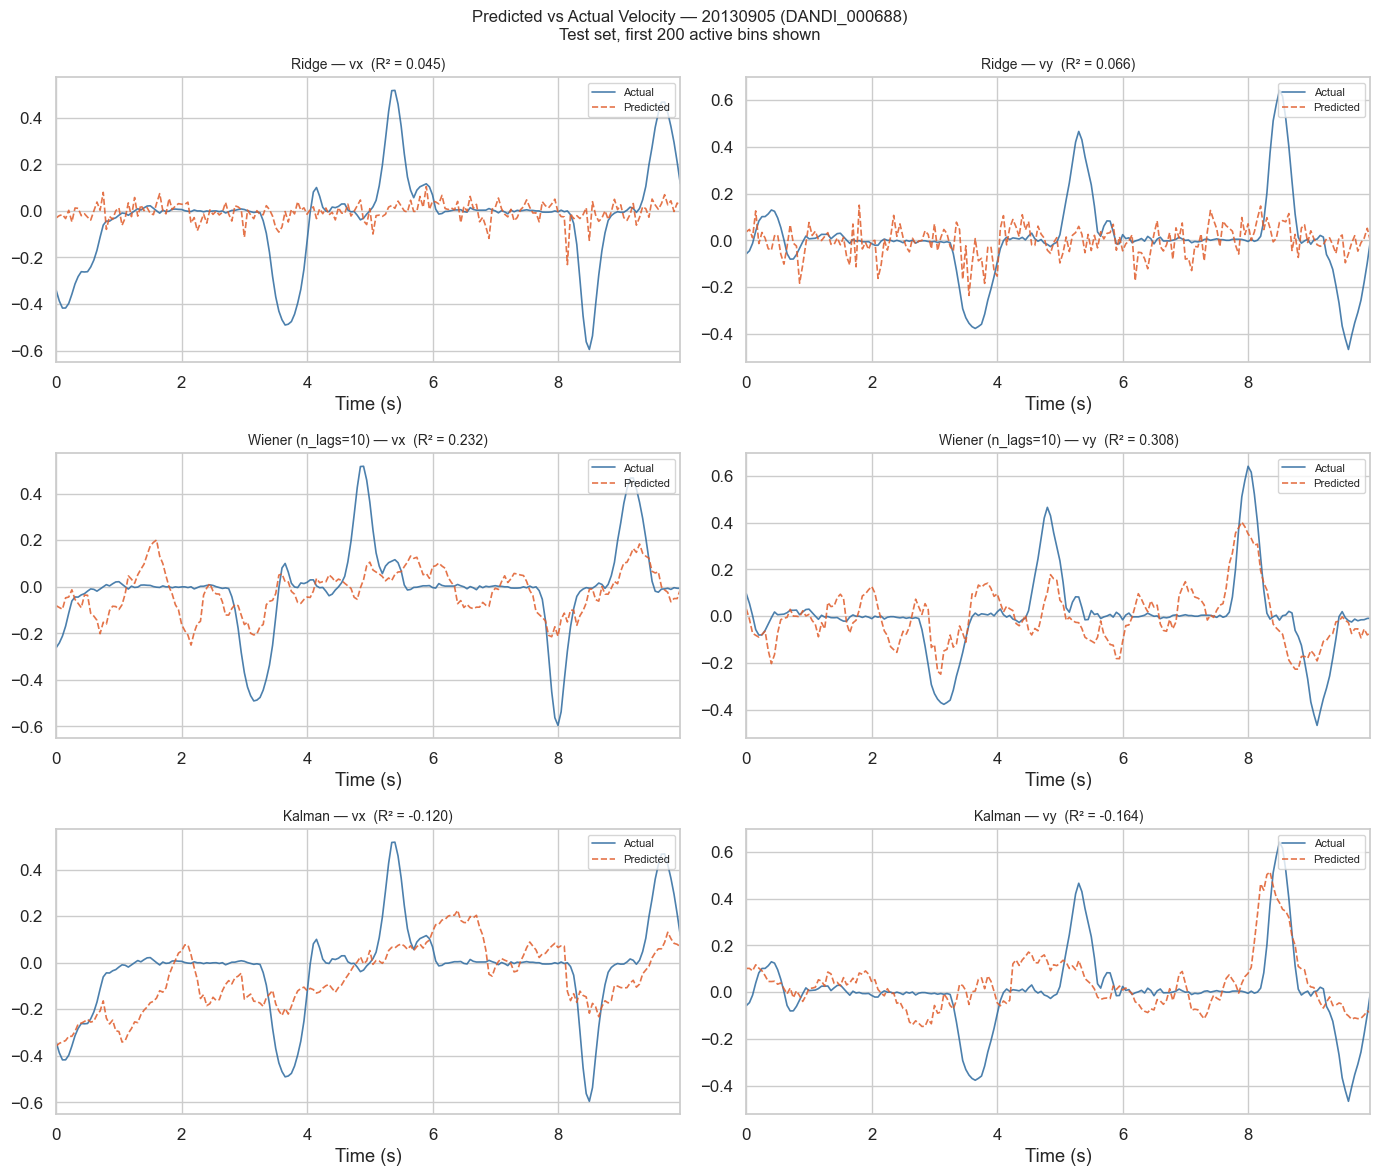

Saved: 01_ContinuousDecoding_DANDI688_velocity.png


In [ ]:
pb_r = min(PLOT_BINS, len(y_test))
pb_w = min(PLOT_BINS, len(y_test_wiener))
pb_wr = min(PLOT_BINS, len(y_test_wiener_ridge))
pb_k = min(PLOT_BINS, len(y_test))
t_r  = np.arange(pb_r) * BIN_SIZE_MS / 1000
t_w  = np.arange(pb_w) * BIN_SIZE_MS / 1000
t_wr  = np.arange(pb_wr) * BIN_SIZE_MS / 1000
t_k  = np.arange(pb_k) * BIN_SIZE_MS / 1000

def _plot(ax, t, y_true, y_pred, r2_val, title):
    ax.plot(t, y_true, color="#2d6a9f", lw=1.2, label="Actual",    alpha=0.85)
    ax.plot(t, y_pred, color="#e05c2a", lw=1.2, label="Predicted", ls="--", alpha=0.85)
    ax.set_title(f"{title}  (R² = {r2_val:.3f})", fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim(t[0], t[-1])

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
fig.suptitle(
    f"Predicted vs Actual Velocity — {session_id} (DANDI_000688)\n"
    f"Test set, first {PLOT_BINS} active bins shown",
    fontsize=12,
)

_plot(axes[0, 0], t_r, y_test[:pb_r, 0], y_pred_ridge[:pb_r, 0],   r2_ridge[0],  "Ridge — vx")
_plot(axes[0, 1], t_r, y_test[:pb_r, 1], y_pred_ridge[:pb_r, 1],   r2_ridge[1],  "Ridge — vy")
_plot(axes[1, 0], t_w, y_test_wiener[:pb_w, 0], y_pred_wiener[:pb_w, 0], r2_wiener[0], f"Wiener (n_lags={N_LAGS}) — vx")
_plot(axes[1, 1], t_w, y_test_wiener[:pb_w, 1], y_pred_wiener[:pb_w, 1], r2_wiener[1], f"Wiener (n_lags={N_LAGS}) — vy")
_plot(axes[2, 0], t_wr, y_test_wiener_ridge[:pb_wr, 0], y_pred_wiener_ridge[:pb_wr, 0], r2_wiener_ridge[0], f"Wiener-Ridge (n_lags={N_LAGS}) — vx")
_plot(axes[2, 1], t_wr, y_test_wiener_ridge[:pb_wr, 1], y_pred_wiener_ridge[:pb_wr, 1], r2_wiener_ridge[1], f"Wiener-Ridge (n_lags={N_LAGS}) — vy")
_plot(axes[3, 0], t_k, y_test[:pb_k, 0], y_pred_kalman[:pb_k, 0], r2_kalman[0], "Kalman — vx")
_plot(axes[3, 1], t_k, y_test[:pb_k, 1], y_pred_kalman[:pb_k, 1], r2_kalman[1], "Kalman — vy")

plt.tight_layout()
plt.savefig("01_ContinuousDecoding_DANDI688_velocity.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: 01_ContinuousDecoding_DANDI688_velocity.png")